# Cube Surface Width And Msat Fit

This notebook fits two surface-layer parameters from a tilted magnetic phase target:

1. surface width per face, with a fixed outer cube edge;
2. surface-layer saturation magnetization `Msat`.

The target is synthetic NeuralMag truth. A hard shell generates the truth, a steep sigmoid shell is validated against it, and the fit uses the differentiable soft shell. Adam refines a coarse dynamic-solve grid point with implicit gradients through the dynamic minimizer.


In [ ]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

os.environ.setdefault("JAX_ENABLE_X64", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.95")

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import jax.scipy.ndimage as jsnd
import matplotlib.pyplot as plt
import numpy as np
import optax
try:
    from tqdm.auto import tqdm
except ImportError:
    class _TqdmFallback:
        def __init__(self, iterable, **_kwargs):
            self.iterable = iterable

        def __iter__(self):
            return iter(self.iterable)

        def set_postfix(self, **_kwargs):
            pass

        def write(self, message):
            print(message)

    def tqdm(iterable, **_kwargs):
        return _TqdmFallback(iterable)
import unxt as u

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for path in (repo_root / "src", repo_root / "vendor" / "neuralmag"):
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

import neuralmag as nm
from libertem_holo.base.mbir import MU_0
from libertem_holo.base.mbir.kernel import build_rdfc_kernel, phase_mapper_rdfc

nm.config.dtype = "float64"
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {getattr(nm.config.backend, 'name', nm.config.backend)}")


2026-05-05 11:38:11 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-05-05 11:38:12 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-05-05 11:38:12 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


## Parameters


In [2]:
# Geometry and synthetic truth.
outer_edge_length_nm = 80.0
cell_size_nm = 1.0
truth_surface_width_nm = 5.0
truth_surface_msat_a_per_m = 100e3
random_seed = 21

# Fixed material parameters.
core_msat_a_per_m = 480e3
core_kc_j_per_m3 = -1.3e4
crystal_ku_111_j_per_m3 = 0.0
aex_j_per_m = 1e-11
demag_p = 3

# Soft shell used by the differentiable fit.
shell_softness_nm = 0.15
soft_shell_min_agreement = 0.99
soft_shell_max_volume_error = 0.01

# Truth relaxation controls.
truth_minimise_tol = 5e2
truth_minimise_max_iter = 50_000
truth_tau_min = 1e-18
truth_tau_max = 1e-4

# Inner dynamic BB/Cayley relaxation controls.
fit_inner_tol = 5e2
fit_dynamic_max_iter = 50_000
fit_tau_min = 1e-18
fit_tau_max = 1e-4

# Low-VRAM implicit differentiation through the dynamic minimizer.
tangent_cg_tol = 1e-3
tangent_cg_atol = 1e-5
tangent_cg_maxiter = 50
tangent_cg_damping = 1e-6
tangent_basis_check_tol = 1e-6
public_minimise_max_iter = 50_000

# Tilted target phase.
phase_padding_px = 64
tilt_rotation_deg = 45.0
tilt_deg = 45.0
target_crop_margin_px = 8

# Initial coarse dynamic-solve grid search.
width_bounds_nm = (1.0, 15.0)
surface_msat_bounds_a_per_m = (50e3, 480e3)
width_grid_n = 5
msat_grid_n = 5
grid_log_every = 1

# Adam refinement.
adam_steps = 450
adam_learning_rate = 0.05
adam_final_learning_rate = 0.001
adam_decay_steps = 400
adam_log_every = 1
adam_early_stopping_patience = 25
adam_early_stopping_min_delta = 1e-6

# Strict local dynamic post-polish around the best Adam candidate.
polish_inner_tol = 5e1
polish_dynamic_max_iter = 100_000
polish_width_half_span_nm = 0.4
polish_surface_msat_half_span_a_per_m = 8e3
polish_width_n = 9
polish_surface_msat_n = 9

n = int(round(outer_edge_length_nm / cell_size_nm))
if not np.isclose(n * cell_size_nm, outer_edge_length_nm):
    raise ValueError("outer_edge_length_nm must be an integer multiple of cell_size_nm.")
if truth_surface_width_nm < 0.0 or 2.0 * truth_surface_width_nm >= outer_edge_length_nm:
    raise ValueError("truth_surface_width_nm must be non-negative and less than half the outer edge.")
if width_bounds_nm[0] < 0.0 or 2.0 * width_bounds_nm[1] >= outer_edge_length_nm:
    raise ValueError("width_bounds_nm must stay inside the fixed outer cube.")
shape_xyz = (n, n, n)
mesh_step_m = (cell_size_nm * 1e-9,) * 3
solver_dtype = jnp.float64
mu0 = jnp.asarray(MU_0.value, dtype=solver_dtype)
rotation_rad = np.deg2rad(tilt_rotation_deg)
tilt_rad = np.deg2rad(tilt_deg)

print(f"Outer cube: {outer_edge_length_nm:g} nm = {n} cells")
print(f"Truth shell: {truth_surface_width_nm:g} nm per face, Ms={truth_surface_msat_a_per_m / 1e3:g} kA/m")
print(f"Crystal Ku along [111]: {crystal_ku_111_j_per_m3:.6g} J/m^3")
print(f"Fit width bounds: {width_bounds_nm[0]:g}-{width_bounds_nm[1]:g} nm")
print(f"Fit Msat bounds: {surface_msat_bounds_a_per_m[0] / 1e3:g}-{surface_msat_bounds_a_per_m[1] / 1e3:g} kA/m")
print(
    f"Tangent CG: tol={tangent_cg_tol:g}, atol={tangent_cg_atol:g}, "
    f"maxiter={tangent_cg_maxiter}, damping={tangent_cg_damping:g}, "
    f"basis_tol={tangent_basis_check_tol:g}"
)
print(
    f"Adam: steps={adam_steps}, lr={adam_learning_rate:g}->{adam_final_learning_rate:g} (cosine decay), "
    f"decay_steps={adam_decay_steps}, early_stopping_patience={adam_early_stopping_patience}, "
    f"min_delta={adam_early_stopping_min_delta:g} rad"
)
print(
    f"Dynamic polish: tol={polish_inner_tol:g}, max_iter={polish_dynamic_max_iter:,}, "
    f"grid={polish_width_n}x{polish_surface_msat_n}, "
    f"span=+/-{polish_width_half_span_nm:g} nm and "
    f"+/-{polish_surface_msat_half_span_a_per_m / 1e3:g} kA/m"
)

Outer cube: 80 nm = 80 cells
Truth shell: 5 nm per face, Ms=100 kA/m
Crystal Ku along [111]: 0 J/m^3
Fit width bounds: 1-15 nm
Fit Msat bounds: 50-480 kA/m
Tangent CG: tol=0.001, atol=1e-05, maxiter=50, damping=1e-06, basis_tol=1e-06
Adam: steps=450, lr=0.05->0.001 (cosine decay), decay_steps=400, early_stopping_patience=25, min_delta=1e-06 rad
Dynamic polish: tol=50, max_iter=100,000, grid=9x9, span=+/-0.4 nm and +/-8 kA/m


## Geometry And Material Helpers


In [3]:
def cell_centers_np(shape_xyz, spacing_nm):
    axes = [
        (np.arange(size, dtype=np.float64) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape_xyz
    ]
    return np.meshgrid(*axes, indexing="ij")


def cell_centers_jax(shape_xyz, spacing_nm, dtype=solver_dtype):
    axes = [
        (jnp.arange(size, dtype=dtype) + 0.5) * spacing_nm - (size * spacing_nm / 2.0)
        for size in shape_xyz
    ]
    return jnp.meshgrid(*axes, indexing="ij")


xx_np, yy_np, zz_np = cell_centers_np(shape_xyz, cell_size_nm)
max_abs_np = np.maximum.reduce([np.abs(xx_np), np.abs(yy_np), np.abs(zz_np)])
xx_jax, yy_jax, zz_jax = cell_centers_jax(shape_xyz, cell_size_nm)
max_abs_jax = jnp.maximum(jnp.maximum(jnp.abs(xx_jax), jnp.abs(yy_jax)), jnp.abs(zz_jax))


def hard_shell_weights(surface_width_nm):
    inner_half_nm = outer_edge_length_nm / 2.0 - float(surface_width_nm)
    core = (max_abs_np <= inner_half_nm).astype(np.float64)
    surface = 1.0 - core
    return core, surface


def soft_shell_weights(surface_width_nm, softness_nm=shell_softness_nm):
    width = jnp.asarray(surface_width_nm, dtype=solver_dtype)
    inner_half_nm = outer_edge_length_nm / 2.0 - width
    signed_margin_nm = inner_half_nm - max_abs_jax
    core = jax.nn.sigmoid(signed_margin_nm / float(softness_nm))
    surface = 1.0 - core
    return core, surface


def material_fields_from_weights(core_weight, surface_weight, surface_msat_a_per_m):
    surface_msat = jnp.asarray(surface_msat_a_per_m, dtype=solver_dtype)
    ms = core_weight * core_msat_a_per_m + surface_weight * surface_msat
    kc = core_weight * core_kc_j_per_m3
    return ms.astype(solver_dtype), kc.astype(solver_dtype)


def hard_material_fields(surface_width_nm, surface_msat_a_per_m):
    core_weight, surface_weight = hard_shell_weights(surface_width_nm)
    ms = core_weight * core_msat_a_per_m + surface_weight * float(surface_msat_a_per_m)
    kc = core_weight * core_kc_j_per_m3
    return core_weight, surface_weight, ms.astype(np.float64), kc.astype(np.float64)


def normalize_np(values):
    values = np.asarray(values, dtype=np.float64)
    norm = np.linalg.norm(values, axis=-1, keepdims=True)
    return values / np.where(norm > 0.0, norm, 1.0)


def normalize_jax(values):
    norm = jnp.linalg.norm(values, axis=-1, keepdims=True)
    return values / jnp.maximum(norm, jnp.finfo(values.dtype).eps)


def vortex_111_basis_np():
    axis = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    axis /= np.linalg.norm(axis)

    basis_1 = np.array([1.0, -1.0, 0.0], dtype=np.float64)
    basis_1 -= np.dot(basis_1, axis) * axis
    basis_1 /= np.linalg.norm(basis_1)

    basis_2 = np.cross(axis, basis_1)
    basis_2 /= np.linalg.norm(basis_2)
    return axis, basis_1, basis_2


vortex_axis_111_np, vortex_basis1_np, vortex_basis2_np = vortex_111_basis_np()


def project_to_vortex_111_frame(values_xyz):
    values = np.asarray(values_xyz, dtype=np.float64)
    return (
        np.tensordot(values, vortex_basis1_np, axes=([-1], [0])),
        np.tensordot(values, vortex_basis2_np, axes=([-1], [0])),
        np.tensordot(values, vortex_axis_111_np, axes=([-1], [0])),
    )


def initial_magnetization(surface_width_nm, seed):
    core_weight, surface_weight = hard_shell_weights(surface_width_nm)
    coords_xyz = np.stack([xx_np, yy_np, zz_np], axis=-1)
    axial_coord = np.tensordot(coords_xyz, vortex_axis_111_np, axes=([-1], [0]))
    radial_xyz = coords_xyz - axial_coord[..., None] * vortex_axis_111_np
    radial_b1 = np.tensordot(radial_xyz, vortex_basis1_np, axes=([-1], [0]))
    radial_b2 = np.tensordot(radial_xyz, vortex_basis2_np, axes=([-1], [0]))
    phi = np.arctan2(radial_b2, radial_b1)

    in_plane = (
        -np.sin(phi)[..., None] * vortex_basis1_np
        + np.cos(phi)[..., None] * vortex_basis2_np
    )
    axial_component = 0.15 * np.tanh(axial_coord / (0.2 * outer_edge_length_nm))
    vortex = normalize_np(in_plane + axial_component[..., None] * vortex_axis_111_np)

    rng = np.random.default_rng(seed)
    random_surface = normalize_np(rng.normal(size=vortex.shape))
    return normalize_np(core_weight[..., None] * vortex + surface_weight[..., None] * random_surface)


def plot_initial_vortex_111_check(surface_width_nm, seed, slab_half_thickness_nm=None):
    if slab_half_thickness_nm is None:
        slab_half_thickness_nm = cell_size_nm

    m_xyz = initial_magnetization(surface_width_nm, seed)
    coords_xyz = np.stack([xx_np, yy_np, zz_np], axis=-1)
    axial_coord = np.tensordot(coords_xyz, vortex_axis_111_np, axes=([-1], [0]))
    radial_xyz = coords_xyz - axial_coord[..., None] * vortex_axis_111_np
    radial_b1 = np.tensordot(radial_xyz, vortex_basis1_np, axes=([-1], [0]))
    radial_b2 = np.tensordot(radial_xyz, vortex_basis2_np, axes=([-1], [0]))
    m_b1, m_b2, m_parallel = project_to_vortex_111_frame(m_xyz)

    slab_mask = np.abs(axial_coord) <= float(slab_half_thickness_nm)
    near_axis_mask = np.sqrt(radial_b1**2 + radial_b2**2) <= 1.5 * cell_size_nm

    fig, axs = plt.subplots(1, 3, figsize=(15.0, 4.0), constrained_layout=True)
    mid = n // 2

    im = axs[0].imshow(m_parallel[:, :, mid].T, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    axs[0].set_title(r"$m \cdot [111]$ on the $z$ mid-plane")
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

    slab_indices = np.flatnonzero(slab_mask)
    stride = max(1, slab_indices.size // 700)
    sample = slab_indices[::stride]
    scatter = axs[1].scatter(
        radial_b1[slab_mask],
        radial_b2[slab_mask],
        c=m_parallel[slab_mask],
        s=10,
        cmap="RdBu_r",
        vmin=-1.0,
        vmax=1.0,
        alpha=0.7,
    )
    axs[1].quiver(
        radial_b1.reshape(-1)[sample],
        radial_b2.reshape(-1)[sample],
        m_b1.reshape(-1)[sample],
        m_b2.reshape(-1)[sample],
        angles="xy",
        scale_units="xy",
        scale=0.35,
        color="black",
        width=0.0025,
        alpha=0.7,
    )
    axs[1].set_aspect("equal")
    axs[1].set_title("Near-central slice in the plane normal to [111]")
    axs[1].set_xlabel("basis 1 coordinate (nm)")
    axs[1].set_ylabel("basis 2 coordinate (nm)")
    fig.colorbar(scatter, ax=axs[1], fraction=0.046, pad=0.04)

    axial_values = axial_coord[near_axis_mask]
    parallel_values = m_parallel[near_axis_mask]
    order = np.argsort(axial_values)
    axs[2].plot(axial_values[order], parallel_values[order], ".", ms=3)
    axs[2].set_title(r"Near-axis $m \cdot [111]$ profile")
    axs[2].set_xlabel("coordinate along [111] (nm)")
    axs[2].set_ylabel(r"$m \cdot [111]$")
    axs[2].grid(True, alpha=0.25)

    plt.show()
    return m_xyz


def xyz_to_zyx(values):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return np.transpose(np.asarray(values), axes)


def xyz_to_zyx_jax(values):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return jnp.transpose(values, axes)


def pad_xyz_jax(values, pad_px):
    if pad_px <= 0:
        return values
    pad_width = ((pad_px, pad_px), (pad_px, pad_px), (pad_px, pad_px))
    if values.ndim == 4:
        pad_width = pad_width + ((0, 0),)
    return jnp.pad(values, pad_width)


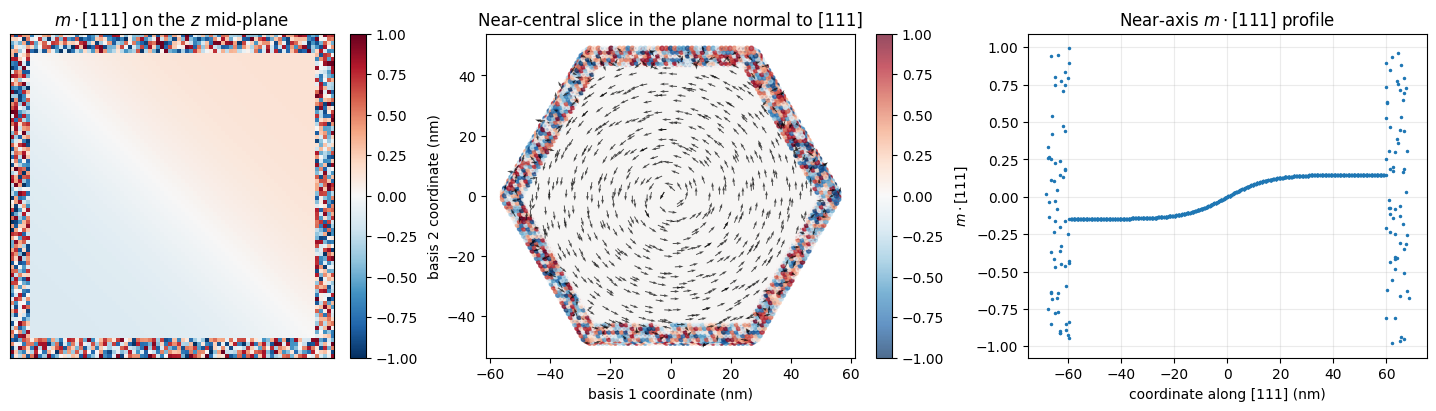

Plotted the 111 vortex seed used as the truth initializer.


In [4]:
seed_m0_cell = plot_initial_vortex_111_check(truth_surface_width_nm, random_seed)
print("Plotted the 111 vortex seed used as the truth initializer.")

## Soft Shell Verification


Mask agreement: 100.000%
Core volume error: 0.000%
Surface volume error: 0.000%


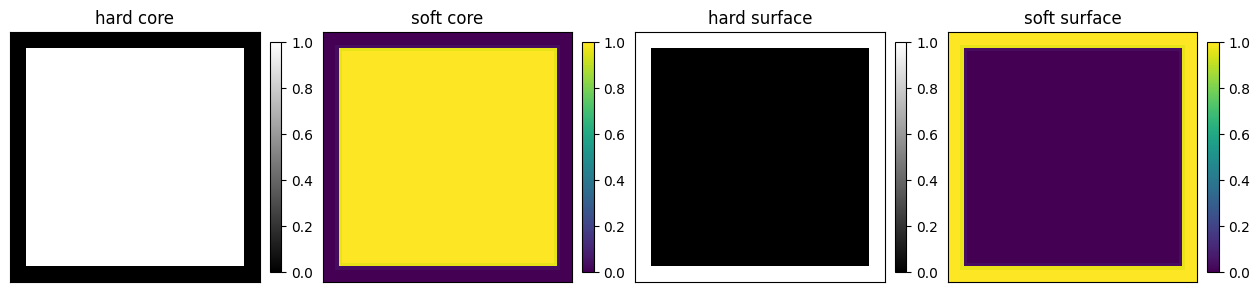

In [5]:
hard_core, hard_surface = hard_shell_weights(truth_surface_width_nm)
soft_core = np.asarray(jax.device_get(soft_shell_weights(truth_surface_width_nm)[0]))
soft_core_binary = soft_core > 0.5
hard_core_binary = hard_core > 0.5

mask_agreement = float(np.mean(soft_core_binary == hard_core_binary))
hard_core_volume = float(hard_core.sum())
soft_core_volume = float(soft_core_binary.sum())
core_volume_error = abs(soft_core_volume - hard_core_volume) / max(hard_core_volume, 1.0)
hard_surface_volume = float(hard_surface.sum())
soft_surface_volume = float((~soft_core_binary).sum())
surface_volume_error = abs(soft_surface_volume - hard_surface_volume) / max(hard_surface_volume, 1.0)

print(f"Mask agreement: {100.0 * mask_agreement:.3f}%")
print(f"Core volume error: {100.0 * core_volume_error:.3f}%")
print(f"Surface volume error: {100.0 * surface_volume_error:.3f}%")
if mask_agreement < soft_shell_min_agreement or max(core_volume_error, surface_volume_error) > soft_shell_max_volume_error:
    print("WARNING: soft shell does not match the hard shell closely enough; reduce shell_softness_nm before trusting the fit.")

mid = n // 2
fig, axs = plt.subplots(1, 4, figsize=(12.5, 3.0), constrained_layout=True)
for ax, image, title, vmin, vmax, cmap in [
    (axs[0], hard_core[:, :, mid].T, "hard core", 0, 1, "gray"),
    (axs[1], soft_core[:, :, mid].T, "soft core", 0, 1, "viridis"),
    (axs[2], hard_surface[:, :, mid].T, "hard surface", 0, 1, "gray"),
    (axs[3], (1.0 - soft_core[:, :, mid]).T, "soft surface", 0, 1, "viridis"),
]:
    im = ax.imshow(image, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## NeuralMag State And Phase Helpers


In [ ]:
def constant_vector_cell_function(state, vector_xyz):
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_vectors_to_node_function(state, values_xyz):
    cell = nm.VectorCellFunction(state, tensor=state.tensor(values_xyz, dtype=state.dtype))
    node = np.asarray(cell.to_node().tensor)
    return nm.VectorFunction(state, tensor=state.tensor(normalize_np(node), dtype=state.dtype))


def build_cube_state(m_cell, ms_field, kc_field, ku_111_j_per_m3=crystal_ku_111_j_per_m3):
    state = nm.State(nm.Mesh(shape_xyz, mesh_step_m))
    state.t = state.tensor(0.0)
    state.rho = nm.CellFunction(state).fill(1.0)
    state.material.Ms = nm.CellFunction(state, tensor=state.tensor(np.asarray(ms_field, dtype=np.float64), dtype=state.dtype))
    state.material.A = nm.CellFunction(state).fill(aex_j_per_m)
    state.material.Kc = nm.CellFunction(state, tensor=state.tensor(np.asarray(kc_field, dtype=np.float64), dtype=state.dtype))

    axis_111 = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    axis_111 /= np.linalg.norm(axis_111)
    axis_1m10 = np.array([1.0, -1.0, 0.0], dtype=np.float64)
    axis_1m10 -= np.dot(axis_1m10, axis_111) * axis_111
    axis_1m10 /= np.linalg.norm(axis_1m10)
    axis_11m2 = np.cross(axis_111, axis_1m10)

    state.material.Kc_axis1 = constant_vector_cell_function(state, axis_111)
    state.material.Kc_axis2 = constant_vector_cell_function(state, axis_1m10)
    state.material.Kc_axis3 = constant_vector_cell_function(state, axis_11m2)
    state.m = cell_vectors_to_node_function(state, m_cell)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.CubicAnisotropyField().register(state, "cubic")
    nm.TotalField("exchange", "demag", "cubic").register(state)
    return state


def unit_node_projection(m_node):
    return normalize_jax(m_node)


def dynamic_minimizer_kwargs(tol, max_iter):
    return dict(
        method="alternating",
        update="cayley",
        projection=unit_node_projection,
        tau_min=truth_tau_min,
        tau_max=truth_tau_max,
        tol=tol,
        max_iter=max_iter,
    )


def cell_from_state(state):
    return normalize_np(np.asarray(state.m.to_cell().tensor))


def _rotation_matrix_z_np(angle):
    c = np.cos(float(angle))
    s = np.sin(float(angle))
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]], dtype=np.float64)


def _rotation_matrix_x_np(angle):
    c = np.cos(float(angle))
    s = np.sin(float(angle))
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]], dtype=np.float64)


def tilt_rotation_matrix_np(rotation, tilt):
    return _rotation_matrix_z_np(-rotation) @ _rotation_matrix_x_np(tilt) @ _rotation_matrix_z_np(rotation)


def tilted_projection_geometry(dim_zyx, rotation, tilt, dim_uv=None):
    dim_z, dim_y, dim_x = (int(v) for v in dim_zyx)
    rot = tilt_rotation_matrix_np(rotation, tilt)

    half_extents = np.array([dim_x, dim_y, dim_z], dtype=np.float64) / 2.0
    corners = np.array(np.meshgrid([-1.0, 1.0], [-1.0, 1.0], [-1.0, 1.0], indexing="ij")).reshape(3, -1).T
    rotated = (corners * half_extents) @ rot.T
    span_u = rotated[:, 0].max() - rotated[:, 0].min()
    span_v = rotated[:, 1].max() - rotated[:, 1].min()
    span_t = rotated[:, 2].max() - rotated[:, 2].min()

    if dim_uv is None:
        dim_uv = (max(1, int(np.ceil(span_v))), max(1, int(np.ceil(span_u))))
    dim_t = max(1, int(np.ceil(span_t)))

    dim_v, dim_u = (int(v) for v in dim_uv)
    t = np.arange(dim_t, dtype=np.float64) + 0.5 - dim_t / 2.0
    v = np.arange(dim_v, dtype=np.float64) + 0.5 - dim_v / 2.0
    u_axis = np.arange(dim_u, dtype=np.float64) + 0.5 - dim_u / 2.0
    tt, vv, uu = np.meshgrid(t, v, u_axis, indexing="ij")
    detector_xyz = np.stack([uu, vv, tt], axis=0).reshape(3, -1)
    volume_xyz = rot.T @ detector_xyz

    x_idx = volume_xyz[0] + dim_x / 2.0 - 0.5
    y_idx = volume_xyz[1] + dim_y / 2.0 - 0.5
    z_idx = volume_xyz[2] + dim_z / 2.0 - 0.5
    coords_zyx = np.stack([z_idx, y_idx, x_idx], axis=0)
    return {
        "dim_uv": (dim_v, dim_u),
        "dim_t": dim_t,
        "coords_zyx": jnp.asarray(coords_zyx, dtype=solver_dtype),
        "coeff": jnp.asarray(rot[:2, :], dtype=solver_dtype),
    }


padded_dim_zyx = (n + 2 * phase_padding_px, n + 2 * phase_padding_px, n + 2 * phase_padding_px)
tilted_geometry = tilted_projection_geometry(padded_dim_zyx, rotation_rad, tilt_rad)
tilted_dim_uv = tilted_geometry["dim_uv"]
tilted_rdfc_kernel = build_rdfc_kernel(tilted_dim_uv, geometry="disc", dtype=solver_dtype)


def tilted_project_jax(volume_zyx):
    components_first = jnp.moveaxis(volume_zyx, -1, 0)
    out_shape = (tilted_geometry["dim_t"], tilted_dim_uv[0], tilted_dim_uv[1])

    def sample_component(field):
        sampled = jsnd.map_coordinates(
            field,
            tilted_geometry["coords_zyx"],
            order=1,
            mode="constant",
            cval=0.0,
        )
        return sampled.reshape(out_shape)

    sampled = jax.vmap(sample_component, in_axes=0, out_axes=0)(components_first)
    summed = jnp.sum(jnp.moveaxis(sampled, 0, -1), axis=0)
    return jnp.einsum("...c,oc->...o", summed, tilted_geometry["coeff"])


def tilted_phase_from_induction_jax(induction_zyx):
    projected = tilted_project_jax(induction_zyx)
    phase_density = (float(cell_size_nm) ** 2) * phase_mapper_rdfc(
        projected[..., 0],
        projected[..., 1],
        tilted_rdfc_kernel,
    )
    return phase_density


def phase_from_cell_jax(m_cell_xyz, ms_field_xyz):
    m_cell_xyz = normalize_jax(m_cell_xyz)
    induction_xyz = m_cell_xyz * (mu0 * ms_field_xyz[..., None])
    induction_zyx = xyz_to_zyx_jax(pad_xyz_jax(induction_xyz, phase_padding_px))
    return tilted_phase_from_induction_jax(induction_zyx)


def support_mask_for_tilted_projection():
    support_xyz = jnp.ones(shape_xyz, dtype=solver_dtype)
    support_zyx = xyz_to_zyx_jax(pad_xyz_jax(support_xyz, phase_padding_px))
    support_vec_zyx = jnp.repeat(support_zyx[..., None], 3, axis=-1)
    projected = tilted_project_jax(support_vec_zyx)
    return np.linalg.norm(np.asarray(jax.device_get(projected)), axis=-1) > 1e-8


def crop_from_mask(mask_yx, margin_px=target_crop_margin_px):
    ys, xs = np.where(mask_yx)
    if ys.size == 0 or xs.size == 0:
        raise ValueError("Cannot crop an empty support mask.")
    y0 = max(int(ys.min()) - int(margin_px), 0)
    y1 = min(int(ys.max()) + int(margin_px) + 1, mask_yx.shape[0])
    x0 = max(int(xs.min()) - int(margin_px), 0)
    x1 = min(int(xs.max()) + int(margin_px) + 1, mask_yx.shape[1])
    return slice(y0, y1), slice(x0, x1)


def mean_subtracted_rms(prediction, target):
    prediction = prediction - jnp.mean(prediction)
    target = target - jnp.mean(target)
    residual = prediction - target
    return jnp.sqrt(jnp.mean(residual * residual))


def center_np(values):
    values = np.asarray(values, dtype=np.float64)
    return values - values.mean()


def mean_subtracted_residual_np(prediction, target):
    return center_np(prediction) - center_np(target)


def mean_subtracted_rms_np(prediction, target):
    residual = mean_subtracted_residual_np(prediction, target)
    return float(np.sqrt(np.mean(residual * residual)))


print(f"Tilted detector shape: {tilted_dim_uv}, beam samples: {tilted_geometry['dim_t']}")

Tilted detector shape: (312, 312), beam samples: 356


## Synthetic Truth Target


In [7]:
truth_core, truth_surface, truth_ms_field, truth_kc_field = hard_material_fields(
    truth_surface_width_nm,
    truth_surface_msat_a_per_m,
)
m0_cell = initial_magnetization(truth_surface_width_nm, random_seed)
truth_state = build_cube_state(m0_cell, truth_ms_field, truth_kc_field)
truth_initial_energy = float(np.asarray(truth_state.E))
truth_minimizer = nm.EnergyMinimizer(
    truth_state,
    **dynamic_minimizer_kwargs(truth_minimise_tol, truth_minimise_max_iter),
)
truth_max_g, truth_info = truth_minimizer.minimise(return_info=True)
truth_final_energy = float(np.asarray(truth_state.E))
truth_m_cell = cell_from_state(truth_state)

support_mask_yx = support_mask_for_tilted_projection()
target_crop_y, target_crop_x = crop_from_mask(support_mask_yx)
target_phase_yx = np.asarray(jax.device_get(phase_from_cell_jax(
    jnp.asarray(truth_m_cell, dtype=solver_dtype),
    jnp.asarray(truth_ms_field, dtype=solver_dtype),
)), dtype=np.float64)
target_phase_crop = target_phase_yx[target_crop_y, target_crop_x]
tilted_dim_uv = tuple(int(v) for v in target_phase_yx.shape)
tilted_rdfc_kernel = build_rdfc_kernel(tilted_dim_uv, geometry="disc", dtype=solver_dtype)
target_phase_crop_jax = jnp.asarray(target_phase_crop, dtype=solver_dtype)

print(
    f"Truth relaxation: converged={bool(np.asarray(truth_info['converged']))} | "
    f"n_iter={int(np.asarray(truth_info['n_iter'])):,} | "
    f"final max_g={float(np.asarray(truth_max_g)):.6g}"
)
print(
    f"Truth energy: initial={truth_initial_energy:.6e} J | "
    f"final={truth_final_energy:.6e} J"
)
print(f"Target phase shape: {target_phase_yx.shape}, crop shape: {target_phase_crop.shape}")

2026-05-05 11:38:14 NeuralMag:INFO [Mesh] 3D, 80 x 80 x 80 (size = 1e-09 x 1e-09 x 1e-09)
2026-05-05 11:38:14 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-05 11:38:14 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-05-05 11:38:15 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-05 11:38:15 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-05 11:38:15 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-05 11:38:19 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-05-05 11:38:19 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uniaxial', energy: 'E_uniaxial', energy density: 'e_uniaxial')
2026-05-05 11:38:19 NeuralMag:INFO [TotalField] Register state methods (

Truth relaxation: converged=True | n_iter=934 | final max_g=499.799
Truth energy: initial=3.678654e-15 J | final=1.819069e-17 J
Target phase shape: (312, 312), crop shape: (136, 136)


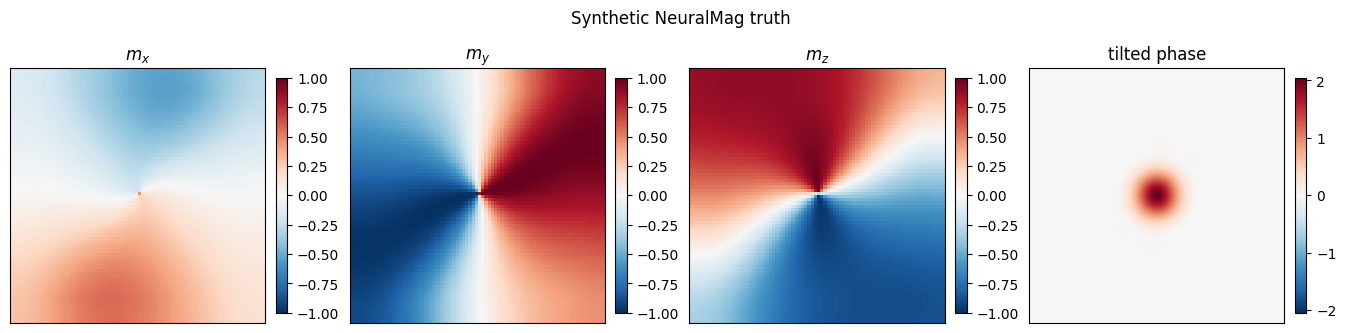

In [8]:
def plot_m_components_and_phase(m_cell, phase_yx, title):
    m_cell = normalize_np(m_cell)
    mid = m_cell.shape[2] // 2
    phase_lim = max(float(np.max(np.abs(phase_yx))), 1e-12)
    panels = [
        (m_cell[:, :, mid, 0].T, "$m_x$", -1.0, 1.0),
        (m_cell[:, :, mid, 1].T, "$m_y$", -1.0, 1.0),
        (m_cell[:, :, mid, 2].T, "$m_z$", -1.0, 1.0),
        (phase_yx, "tilted phase", -phase_lim, phase_lim),
    ]
    fig, axs = plt.subplots(1, 4, figsize=(13.5, 3.5), constrained_layout=True)
    for ax, (image, title_text, vmin, vmax) in zip(axs, panels):
        im = ax.imshow(image, cmap="RdBu_r", vmin=vmin, vmax=vmax)
        ax.set_title(title_text)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


plot_m_components_and_phase(truth_m_cell, target_phase_yx, "Synthetic NeuralMag truth")


## Differentiable Fit Setup


In [9]:
template_ms = np.full(shape_xyz, core_msat_a_per_m, dtype=np.float64)
template_kc = np.full(shape_xyz, core_kc_j_per_m3, dtype=np.float64)
fit_state = build_cube_state(m0_cell, template_ms, template_kc)
fit_minimizer = nm.EnergyMinimizer(
    fit_state,
    method="alternating",
    update="cayley",
    projection=unit_node_projection,
    tau_min=fit_tau_min,
    tau_max=fit_tau_max,
    tol=fit_inner_tol,
    max_iter=fit_dynamic_max_iter,
    parameters=["material__Ms", "material__Kc"],
)
input_m_node = jnp.asarray(fit_state.m.tensor, dtype=solver_dtype)
node_to_cell = fit_state.resolve(fit_state.m._code.to_cell, ["f"])
fit_energy_node = jax.jit(fit_state.resolve("E", ["m", "material__Ms", "material__Kc"]))


def cell_from_node_jax(m_node):
    return normalize_jax(node_to_cell(normalize_jax(m_node)))


def fit_material_fields(surface_width_nm, surface_msat_a_per_m):
    core_weight, surface_weight = soft_shell_weights(surface_width_nm)
    return material_fields_from_weights(core_weight, surface_weight, surface_msat_a_per_m)


def bounded_value(theta, bounds):
    lo, hi = bounds
    return lo + (hi - lo) * jax.nn.sigmoid(theta)


def inverse_bounded_value(value, bounds):
    lo, hi = bounds
    frac = np.clip((float(value) - lo) / (hi - lo), 1e-12, 1.0 - 1e-12)
    return np.log(frac / (1.0 - frac))


def unpack_theta(theta):
    width_nm = bounded_value(theta[0], width_bounds_nm)
    surface_msat = bounded_value(theta[1], surface_msat_bounds_a_per_m)
    return width_nm, surface_msat


def dynamic_minimise_node(initial_m_node, ms_field, kc_field, *, return_info=False):
    return fit_minimizer.solve(
        initial_m_node,
        ms_field,
        kc_field,
        tol=fit_inner_tol,
        max_iter=fit_dynamic_max_iter,
        return_info=return_info,
    )


def tangent_basis_node(m_node):
    m_unit = normalize_jax(m_node)
    axis_index = jnp.argmin(jnp.abs(m_unit), axis=-1)
    reference = jax.nn.one_hot(axis_index, 3, dtype=m_unit.dtype)
    e1 = normalize_jax(reference - jnp.sum(reference * m_unit, axis=-1, keepdims=True) * m_unit)
    e2 = normalize_jax(jnp.cross(m_unit, e1))
    return e1, e2


def tangent_to_cartesian(q, basis):
    e1, e2 = basis
    return q[..., 0:1] * e1 + q[..., 1:2] * e2


def cartesian_to_tangent(vector, basis):
    e1, e2 = basis
    return jnp.stack([
        jnp.sum(vector * e1, axis=-1),
        jnp.sum(vector * e2, axis=-1),
    ], axis=-1)


def retract_tangent(m_node, basis, q):
    return normalize_jax(m_node + tangent_to_cartesian(q, basis))


def tangent_energy_from_q(q, m_node, basis, theta):
    width_nm, surface_msat = unpack_theta(theta)
    ms_field, kc_field = fit_material_fields(width_nm, surface_msat)
    return fit_energy_node(retract_tangent(m_node, basis, q), ms_field, kc_field)


def tangent_energy_gradient(q, m_node, basis, theta):
    return jax.grad(tangent_energy_from_q, argnums=0)(q, m_node, basis, theta)


@jax.custom_vjp
def relaxed_m_for_theta_tangent_cg(theta):
    width_nm, surface_msat = unpack_theta(theta)
    ms_field, kc_field = fit_material_fields(width_nm, surface_msat)
    return normalize_jax(dynamic_minimise_node(input_m_node, ms_field, kc_field))


def relaxed_m_for_theta_tangent_cg_fwd(theta):
    width_nm, surface_msat = unpack_theta(theta)
    ms_field, kc_field = fit_material_fields(width_nm, surface_msat)
    m_star = normalize_jax(dynamic_minimise_node(input_m_node, ms_field, kc_field))
    return m_star, (m_star, theta)


def relaxed_m_for_theta_tangent_cg_bwd(residual, m_bar):
    m_star, theta = residual
    basis = tangent_basis_node(m_star)
    q0 = jnp.zeros(m_star.shape[:-1] + (2,), dtype=m_star.dtype)
    q_bar = cartesian_to_tangent(m_bar, basis)
    damping = jnp.asarray(tangent_cg_damping, dtype=m_star.dtype)

    def tangent_hessian_vector(vector):
        _, hvp = jax.jvp(
            lambda q: tangent_energy_gradient(q, m_star, basis, theta),
            (q0,),
            (vector,),
        )
        return hvp + damping * vector

    lambda_q, _ = jax.scipy.sparse.linalg.cg(
        tangent_hessian_vector,
        q_bar,
        tol=tangent_cg_tol,
        atol=tangent_cg_atol,
        maxiter=tangent_cg_maxiter,
    )

    _, pullback = jax.vjp(lambda theta_inner: tangent_energy_gradient(q0, m_star, basis, theta_inner), theta)
    theta_bar = -pullback(lambda_q)[0]
    return (theta_bar,)


relaxed_m_for_theta_tangent_cg.defvjp(
    relaxed_m_for_theta_tangent_cg_fwd,
    relaxed_m_for_theta_tangent_cg_bwd,
)


def relaxed_m_for_theta(theta):
    return relaxed_m_for_theta_tangent_cg(theta)


def implicit_phase_crop(theta):
    width_nm, surface_msat = unpack_theta(theta)
    ms_field, _ = fit_material_fields(width_nm, surface_msat)
    m_final_node = relaxed_m_for_theta(theta)
    phase_crop, _ = phase_crop_from_node(m_final_node, ms_field)
    return phase_crop


def implicit_loss_only(theta):
    phase_crop = implicit_phase_crop(theta)
    return mean_subtracted_rms(phase_crop, target_phase_crop_jax)


def phase_crop_from_node(m_node, ms_field):
    m_cell = cell_from_node_jax(m_node)
    phase_yx = phase_from_cell_jax(m_cell, ms_field)
    return phase_yx[target_crop_y, target_crop_x], m_cell


def predict_phase_crop_dynamic(surface_width_nm, surface_msat_a_per_m, *, tol=fit_inner_tol, max_iter=fit_dynamic_max_iter):
    ms_field, kc_field = fit_material_fields(surface_width_nm, surface_msat_a_per_m)
    m_final_node = fit_minimizer.solve(
        input_m_node,
        ms_field,
        kc_field,
        tol=tol,
        max_iter=max_iter,
    )
    phase_crop, m_final_cell = phase_crop_from_node(m_final_node, ms_field)
    return phase_crop, m_final_cell


def predict_phase_crop_dynamic_with_info(surface_width_nm, surface_msat_a_per_m, *, tol=fit_inner_tol, max_iter=fit_dynamic_max_iter):
    ms_field, kc_field = fit_material_fields(surface_width_nm, surface_msat_a_per_m)
    m_final_node, info = fit_minimizer.solve(
        input_m_node,
        ms_field,
        kc_field,
        tol=tol,
        max_iter=max_iter,
        return_info=True,
    )
    phase_crop, m_final_cell = phase_crop_from_node(m_final_node, ms_field)
    return phase_crop, m_final_cell, info


def dynamic_loss_from_values(surface_width_nm, surface_msat_a_per_m):
    phase_crop, _ = predict_phase_crop_dynamic(surface_width_nm, surface_msat_a_per_m)
    return mean_subtracted_rms(phase_crop, target_phase_crop_jax)


def dynamic_loss_with_outputs(theta):
    width_nm, surface_msat = unpack_theta(theta)
    phase_crop, m_final_cell, info = predict_phase_crop_dynamic_with_info(width_nm, surface_msat)
    rms = mean_subtracted_rms(phase_crop, target_phase_crop_jax)
    return rms, {
        "width_nm": width_nm,
        "surface_msat_a_per_m": surface_msat,
        "phase_crop": phase_crop,
        "m_final_cell": m_final_cell,
        "inner_n_iter": info["n_iter"],
        "inner_converged": info["converged"],
        "inner_max_g": info["max_g"],
    }


def implicit_loss_value_and_grad(theta):
    return jax.value_and_grad(implicit_loss_only)(theta)


implicit_loss_value_and_grad = jax.jit(implicit_loss_value_and_grad)


def implicit_loss_with_outputs(theta):
    return dynamic_loss_with_outputs(theta)


dynamic_loss_from_values_jit = jax.jit(dynamic_loss_from_values)
implicit_loss_with_outputs_jit = jax.jit(implicit_loss_with_outputs)

print("Fit machinery ready with tangent-CG implicit gradients.")


2026-05-05 11:39:13 NeuralMag:INFO [Mesh] 3D, 80 x 80 x 80 (size = 1e-09 x 1e-09 x 1e-09)
2026-05-05 11:39:13 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-05 11:39:13 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-05-05 11:39:14 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-05 11:39:14 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-05 11:39:14 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-05 11:39:15 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-05-05 11:39:15 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uniaxial', energy: 'E_uniaxial', energy density: 'e_uniaxial')
2026-05-05 11:39:15 NeuralMag:INFO [TotalField] Register state methods (

Fit machinery ready with tangent-CG implicit gradients.


## Vmappable Local Dynamic-Solve Search

Run the NeuralMag dynamic minimiser over an explicit parameter grid and compute the phase RMS loss from the relaxed state. This search uses fixed limits of `1` to `10` nm for surface thickness and `50` to `480` kA/m for surface `Msat`, evaluates candidates in chunks of `20`, and records convergence diagnostics for every solve before selecting the best starting point for Adam.

In [10]:
search_width_limits_nm = (1.0, 10.0)
search_surface_msat_limits_a_per_m = (50e3, 480e3)
search_chunk_size = 2


def candidate_theta_from_values(width_nm, surface_msat_a_per_m):
    return jnp.asarray(
        [
            inverse_bounded_value(width_nm, width_bounds_nm),
            inverse_bounded_value(surface_msat_a_per_m, surface_msat_bounds_a_per_m),
        ],
        dtype=solver_dtype,
    )


def dynamic_minimise_and_loss_from_theta(theta):
    width_nm, surface_msat = unpack_theta(theta)
    ms_field, kc_field = fit_material_fields(width_nm, surface_msat)
    m_final_node, info = fit_minimizer.solve(
        input_m_node,
        ms_field,
        kc_field,
        tol=fit_inner_tol,
        max_iter=fit_dynamic_max_iter,
        return_info=True,
    )
    phase_crop, _ = phase_crop_from_node(m_final_node, ms_field)
    rms = mean_subtracted_rms(phase_crop, target_phase_crop_jax)
    return rms, info["n_iter"], info["converged"], info["max_g"]


dynamic_minimise_and_loss_batch = jax.jit(
    jax.vmap(dynamic_minimise_and_loss_from_theta)
 )

width_search_grid_nm = np.linspace(
    search_width_limits_nm[0],
    search_width_limits_nm[1],
    width_grid_n,
    dtype=np.float64,
 )
surface_msat_search_grid_a_per_m = np.linspace(
    search_surface_msat_limits_a_per_m[0],
    search_surface_msat_limits_a_per_m[1],
    msat_grid_n,
    dtype=np.float64,
 )

search_pairs = [
    (width_nm, surface_msat_a_per_m)
    for width_nm in width_search_grid_nm
    for surface_msat_a_per_m in surface_msat_search_grid_a_per_m
 ]
search_theta_batch = jnp.asarray(
    [candidate_theta_from_values(width_nm, surface_msat_a_per_m) for width_nm, surface_msat_a_per_m in search_pairs],
    dtype=solver_dtype,
 )

n_candidates = len(search_pairs)
search_loss_flat = np.empty(n_candidates, dtype=np.float64)
search_n_iter_flat = np.empty(n_candidates, dtype=np.int64)
search_converged_flat = np.empty(n_candidates, dtype=bool)
search_max_g_flat = np.empty(n_candidates, dtype=np.float64)

search_chunk_starts = range(0, n_candidates, search_chunk_size)
for start in tqdm(search_chunk_starts, total=(n_candidates + search_chunk_size - 1) // search_chunk_size, desc="Vmapped search", unit="chunk"):
    stop = min(start + search_chunk_size, n_candidates)
    chunk_theta = search_theta_batch[start:stop]
    chunk_loss, chunk_n_iter, chunk_converged, chunk_max_g = dynamic_minimise_and_loss_batch(chunk_theta)
    search_loss_flat[start:stop] = np.asarray(jax.device_get(chunk_loss), dtype=np.float64)
    search_n_iter_flat[start:stop] = np.asarray(jax.device_get(chunk_n_iter), dtype=np.int64)
    search_converged_flat[start:stop] = np.asarray(jax.device_get(chunk_converged), dtype=bool)
    search_max_g_flat[start:stop] = np.asarray(jax.device_get(chunk_max_g), dtype=np.float64)

search_loss_grid = search_loss_flat.reshape(width_grid_n, msat_grid_n)
search_n_iter_grid = search_n_iter_flat.reshape(width_grid_n, msat_grid_n)
search_converged_grid = search_converged_flat.reshape(width_grid_n, msat_grid_n)
search_max_g_grid = search_max_g_flat.reshape(width_grid_n, msat_grid_n)

n_not_converged = int(np.count_nonzero(~search_converged_flat))
print(
    f"Vmapped search limits: width={search_width_limits_nm[0]:g}-{search_width_limits_nm[1]:g} nm, "
    f"surface Ms={search_surface_msat_limits_a_per_m[0] / 1e3:g}-{search_surface_msat_limits_a_per_m[1] / 1e3:g} kA/m, "
    f"chunk_size={search_chunk_size}"
 )
print(
    f"Completed {n_candidates} dynamic solves. "
    f"Converged={n_candidates - n_not_converged}/{n_candidates}, "
    f"max observed max_g={float(np.max(search_max_g_flat)):.6g}"
 )

if n_not_converged:
    failed_indices = np.flatnonzero(~search_converged_flat)
    failed_preview = [
        {
            "width_nm": float(search_pairs[index][0]),
            "surface_msat_kA_per_m": float(search_pairs[index][1] / 1e3),
            "n_iter": int(search_n_iter_flat[index]),
            "max_g": float(search_max_g_flat[index]),
        }
        for index in failed_indices[:5]
    ]
    raise RuntimeError(
        f"Dynamic search did not converge for {n_not_converged} candidate(s). "
        f"First failures: {failed_preview}"
    )

search_best_flat_index = int(np.argmin(search_loss_flat))
search_best_width_nm, search_best_surface_msat_a_per_m = search_pairs[search_best_flat_index]
search_best_width_nm = float(search_best_width_nm)
search_best_surface_msat_a_per_m = float(search_best_surface_msat_a_per_m)
search_best_loss = float(search_loss_flat[search_best_flat_index])
search_best_n_iter = int(search_n_iter_flat[search_best_flat_index])
search_best_max_g = float(search_max_g_flat[search_best_flat_index])
search_best_theta = candidate_theta_from_values(
    search_best_width_nm,
    search_best_surface_msat_a_per_m,
 )

print(
    f"Best dynamic-search candidate: width={search_best_width_nm:.4g} nm, "
    f"surface Ms={search_best_surface_msat_a_per_m / 1e3:.4g} kA/m, "
    f"RMS={search_best_loss:.6g} rad, "
    f"n_iter={search_best_n_iter}, max_g={search_best_max_g:.6g}"
 )

Vmapped search:   0%|          | 0/13 [00:00<?, ?chunk/s]

Vmapped search limits: width=1-10 nm, surface Ms=50-480 kA/m, chunk_size=2
Completed 25 dynamic solves. Converged=25/25, max observed max_g=498.298
Best dynamic-search candidate: width=5.5 nm, surface Ms=157.5 kA/m, RMS=0.0114595 rad, n_iter=759, max_g=487.132


## Dynamic-Search Loss Grid Inspector

The left panel shows the chunked vmapped search loss grid over surface thickness and surface `Msat`. Click anywhere on the grid to rerun that candidate once and compare its phase crop against the ground truth and the residual.

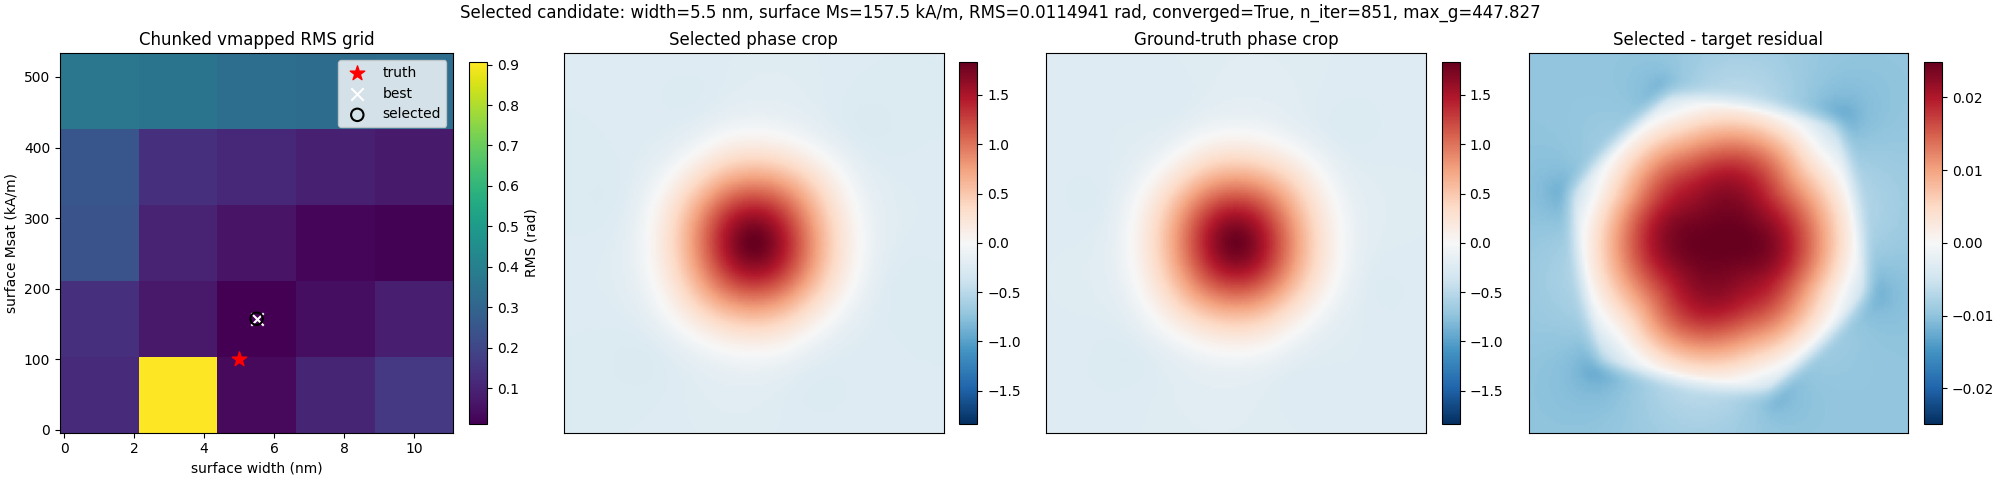

Click the loss grid to inspect a candidate. The selected phase crop, ground truth, and residual will update after a single-candidate recompute.


In [12]:
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass


def grid_edges(values):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 1:
        half_step = 0.5
        return np.array([values[0] - half_step, values[0] + half_step], dtype=np.float64)
    deltas = np.diff(values)
    left_edge = values[0] - 0.5 * deltas[0]
    right_edge = values[-1] + 0.5 * deltas[-1]
    interior_edges = 0.5 * (values[:-1] + values[1:])
    return np.concatenate([[left_edge], interior_edges, [right_edge]])


width_search_edges_nm = grid_edges(width_search_grid_nm)
surface_msat_search_edges_ka_per_m = grid_edges(surface_msat_search_grid_a_per_m / 1e3)

loss_grid_display = search_loss_grid.T
loss_grid_extent = [
    width_search_edges_nm[0],
    width_search_edges_nm[-1],
    surface_msat_search_edges_ka_per_m[0],
    surface_msat_search_edges_ka_per_m[-1],
 ]

search_best_width_index, search_best_msat_index = np.unravel_index(
    int(np.argmin(search_loss_grid)),
    search_loss_grid.shape,
 )

selected_phase_cache = {}


def inspect_search_candidate(width_index, msat_index):
    width_index = int(np.clip(width_index, 0, width_grid_n - 1))
    msat_index = int(np.clip(msat_index, 0, msat_grid_n - 1))
    cache_key = (width_index, msat_index)
    width_nm = float(width_search_grid_nm[width_index])
    surface_msat_a_per_m = float(surface_msat_search_grid_a_per_m[msat_index])

    if cache_key not in selected_phase_cache:
        phase_crop, _m_cell, info = predict_phase_crop_dynamic_with_info(
            width_nm,
            surface_msat_a_per_m,
        )
        phase_crop_np = np.asarray(jax.device_get(phase_crop), dtype=np.float64)
        selected_phase_cache[cache_key] = {
            "phase_crop": phase_crop_np,
            "n_iter": int(np.asarray(info["n_iter"])),
            "converged": bool(np.asarray(info["converged"])),
            "max_g": float(np.asarray(info["max_g"])),
        }

    cached = selected_phase_cache[cache_key]
    phase_crop_np = cached["phase_crop"]
    target_centered = target_phase_crop - target_phase_crop.mean()
    phase_centered = phase_crop_np - phase_crop_np.mean()
    residual = phase_centered - target_centered
    rms = float(np.sqrt(np.mean(residual * residual)))
    return {
        "width_index": width_index,
        "msat_index": msat_index,
        "width_nm": width_nm,
        "surface_msat_a_per_m": surface_msat_a_per_m,
        "phase_crop": phase_crop_np,
        "target_centered": target_centered,
        "phase_centered": phase_centered,
        "residual": residual,
        "rms": rms,
        "n_iter": cached["n_iter"],
        "converged": cached["converged"],
        "max_g": cached["max_g"],
    }


initial_candidate = inspect_search_candidate(search_best_width_index, search_best_msat_index)
phase_lim = max(
    float(np.max(np.abs(initial_candidate["target_centered"]))),
    float(np.max(np.abs(initial_candidate["phase_centered"]))),
    1e-12,
 )
resid_lim = max(float(np.max(np.abs(initial_candidate["residual"]))), 1e-12)

fig, axs = plt.subplots(1, 4, figsize=(20.0, 4.8), constrained_layout=True)
loss_im = axs[0].imshow(
    loss_grid_display,
    origin="lower",
    aspect="auto",
    extent=loss_grid_extent,
    cmap="viridis",
 )
axs[0].set_title("Chunked vmapped RMS grid")
axs[0].set_xlabel("surface width (nm)")
axs[0].set_ylabel("surface Msat (kA/m)")
axs[0].scatter(
    [truth_surface_width_nm],
    [truth_surface_msat_a_per_m / 1e3],
    marker="*",
    s=120,
    c="red",
    label="truth",
 )
axs[0].scatter(
    [search_best_width_nm],
    [search_best_surface_msat_a_per_m / 1e3],
    marker="x",
    s=80,
    c="white",
    label="best",
 )
selected_marker = axs[0].scatter(
    [initial_candidate["width_nm"]],
    [initial_candidate["surface_msat_a_per_m"] / 1e3],
    marker="o",
    s=80,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="selected",
 )
axs[0].legend(loc="upper right")
fig.colorbar(loss_im, ax=axs[0], fraction=0.046, pad=0.04, label="RMS (rad)")

phase_im = axs[1].imshow(
    initial_candidate["phase_centered"],
    cmap="RdBu_r",
    vmin=-phase_lim,
    vmax=phase_lim,
 )
axs[1].set_title("Selected phase crop")
axs[1].set_xticks([])
axs[1].set_yticks([])
fig.colorbar(phase_im, ax=axs[1], fraction=0.046, pad=0.04)

target_im = axs[2].imshow(
    initial_candidate["target_centered"],
    cmap="RdBu_r",
    vmin=-phase_lim,
    vmax=phase_lim,
 )
axs[2].set_title("Ground-truth phase crop")
axs[2].set_xticks([])
axs[2].set_yticks([])
fig.colorbar(target_im, ax=axs[2], fraction=0.046, pad=0.04)

resid_im = axs[3].imshow(
    initial_candidate["residual"],
    cmap="RdBu_r",
    vmin=-resid_lim,
    vmax=resid_lim,
 )
axs[3].set_title("Selected - target residual")
axs[3].set_xticks([])
axs[3].set_yticks([])
fig.colorbar(resid_im, ax=axs[3], fraction=0.046, pad=0.04)

suptitle = fig.suptitle(
    f"Selected candidate: width={initial_candidate['width_nm']:.4g} nm, "
    f"surface Ms={initial_candidate['surface_msat_a_per_m'] / 1e3:.4g} kA/m, "
    f"RMS={initial_candidate['rms']:.6g} rad, "
    f"converged={initial_candidate['converged']}, "
    f"n_iter={initial_candidate['n_iter']}, max_g={initial_candidate['max_g']:.6g}"
 )


def update_candidate_display(candidate):
    selected_marker.set_offsets([[candidate["width_nm"], candidate["surface_msat_a_per_m"] / 1e3]])

    phase_lim = max(
        float(np.max(np.abs(candidate["target_centered"]))),
        float(np.max(np.abs(candidate["phase_centered"]))),
        1e-12,
    )
    resid_lim = max(float(np.max(np.abs(candidate["residual"]))), 1e-12)

    phase_im.set_data(candidate["phase_centered"])
    phase_im.set_clim(-phase_lim, phase_lim)
    target_im.set_data(candidate["target_centered"])
    target_im.set_clim(-phase_lim, phase_lim)
    resid_im.set_data(candidate["residual"])
    resid_im.set_clim(-resid_lim, resid_lim)

    suptitle.set_text(
        f"Selected candidate: width={candidate['width_nm']:.4g} nm, "
        f"surface Ms={candidate['surface_msat_a_per_m'] / 1e3:.4g} kA/m, "
        f"RMS={candidate['rms']:.6g} rad, "
        f"converged={candidate['converged']}, "
        f"n_iter={candidate['n_iter']}, max_g={candidate['max_g']:.6g}"
    )
    fig.canvas.draw_idle()


def on_loss_grid_click(event):
    if event.inaxes != axs[0] or event.xdata is None or event.ydata is None:
        return

    width_index = int(np.argmin(np.abs(width_search_grid_nm - float(event.xdata))))
    msat_index = int(
        np.argmin(np.abs(surface_msat_search_grid_a_per_m / 1e3 - float(event.ydata)))
    )
    candidate = inspect_search_candidate(width_index, msat_index)
    update_candidate_display(candidate)


click_callback = fig.canvas.mpl_connect("button_press_event", on_loss_grid_click)
plt.show()

print(
    "Click the loss grid to inspect a candidate. "
    "The selected phase crop, ground truth, and residual will update after a single-candidate recompute."
 )

## Theta0 Tangent-CG Diagnostics

Prepare the grid-search winner for all following fit diagnostics and check the current tangent-CG implicit gradient at that point.


In [ ]:
theta0 = jnp.asarray(search_best_theta, dtype=solver_dtype)


def host_dict(values):
    return {key: jax.device_get(value) for key, value in values.items()}


print(
    f"Adam initialization from vmapped local search: width={search_best_width_nm:.4g} nm, "
    f"surface Ms={search_best_surface_msat_a_per_m / 1e3:.4g} kA/m, "
    f"RMS={search_best_loss:.6g} rad"
 )

theta0_dynamic_loss, theta0_dynamic_aux = implicit_loss_with_outputs_jit(theta0)
theta0_dynamic_aux = host_dict(theta0_dynamic_aux)
print(
    f"Dynamic minimise at theta0: RMS={float(np.asarray(jax.device_get(theta0_dynamic_loss))):.6g} rad | "
    f"converged={bool(np.asarray(theta0_dynamic_aux['inner_converged']))} | "
    f"n_iter={int(np.asarray(theta0_dynamic_aux['inner_n_iter'])):,} | "
    f"max_g={float(np.asarray(theta0_dynamic_aux['inner_max_g'])):.6g}"
 )

theta0_width_nm, theta0_surface_msat = unpack_theta(theta0)
theta0_ms_field, theta0_kc_field = fit_material_fields(theta0_width_nm, theta0_surface_msat)
theta0_energy = fit_energy_node(input_m_node, theta0_ms_field, theta0_kc_field)
theta0_tangent_m_node, theta0_tangent_info = dynamic_minimise_node(
    input_m_node,
    theta0_ms_field,
    theta0_kc_field,
    return_info=True,
 )
theta0_tangent_m_node = normalize_jax(theta0_tangent_m_node)
theta0_basis = tangent_basis_node(theta0_tangent_m_node)
theta0_q0 = jnp.zeros(theta0_tangent_m_node.shape[:-1] + (2,), dtype=solver_dtype)
theta0_tangent_grad = tangent_energy_gradient(theta0_q0, theta0_tangent_m_node, theta0_basis, theta0)
theta0_tangent_grad_norm = jnp.sqrt(jnp.sum(theta0_tangent_grad * theta0_tangent_grad, axis=-1)).max()
theta0_e1, theta0_e2 = theta0_basis
theta0_basis_checks = {
    "max_abs_e1_dot_m": jnp.max(jnp.abs(jnp.sum(theta0_e1 * theta0_tangent_m_node, axis=-1))),
    "max_abs_e2_dot_m": jnp.max(jnp.abs(jnp.sum(theta0_e2 * theta0_tangent_m_node, axis=-1))),
    "max_abs_e1_dot_e2": jnp.max(jnp.abs(jnp.sum(theta0_e1 * theta0_e2, axis=-1))),
    "max_abs_e1_norm_error": jnp.max(jnp.abs(jnp.linalg.norm(theta0_e1, axis=-1) - 1.0)),
    "max_abs_e2_norm_error": jnp.max(jnp.abs(jnp.linalg.norm(theta0_e2, axis=-1) - 1.0)),
}
theta0_basis_checks = {key: float(np.asarray(jax.device_get(value))) for key, value in theta0_basis_checks.items()}
print(f"Energy at theta0 input state: {float(np.asarray(jax.device_get(theta0_energy))):.6e} J")
print(
    f"Tangent diagnostic at theta0: dynamic n_iter={int(np.asarray(theta0_tangent_info['n_iter'])):,} | "
    f"max_g={float(np.asarray(theta0_tangent_info['max_g'])):.6g} | "
    f"max tangent |grad_q E|={float(np.asarray(jax.device_get(theta0_tangent_grad_norm))):.6g}"
 )
print(f"Tangent basis max errors: {theta0_basis_checks}")
assert np.isfinite(float(np.asarray(jax.device_get(theta0_energy))))
assert np.isfinite(float(np.asarray(jax.device_get(theta0_tangent_grad_norm))))
assert np.all(np.isfinite(np.array(list(theta0_basis_checks.values()), dtype=np.float64)))
assert max(theta0_basis_checks.values()) <= float(tangent_basis_check_tol)



Adam initialization from vmapped local search: width=5.5 nm, surface Ms=136 kA/m, RMS=0.00265075 rad
Dynamic minimise at theta0: RMS=0.00265084 rad | converged=True | n_iter=799 | max_g=313.918
Energy at theta0 input state: 3.678463e-15 J
Tangent diagnostic at theta0: dynamic n_iter=912 | max_g=457.047 | max tangent |grad_q E|=6.65051e-24
Tangent basis max errors: {'max_abs_e1_dot_m': 3.3306690738754696e-16, 'max_abs_e2_dot_m': 2.2385578703276915e-16, 'max_abs_e1_dot_e2': 1.1102230246251565e-16, 'max_abs_e1_norm_error': 2.220446049250313e-16, 'max_abs_e2_norm_error': 2.220446049250313e-16}


## Gradient Method Microbenchmark

Time compile and one run for the current tangent-CG implicit gradient and direct differentiation through the dynamic solve. Direct AD failures are recorded as benchmark outcomes rather than stopping the notebook.


In [ ]:
def direct_dynamic_loss_only(theta):
    width_nm, surface_msat = unpack_theta(theta)
    ms_field, kc_field = fit_material_fields(width_nm, surface_msat)
    m_final_node = normalize_jax(dynamic_minimise_node(input_m_node, ms_field, kc_field))
    phase_crop, _ = phase_crop_from_node(m_final_node, ms_field)
    return mean_subtracted_rms(phase_crop, target_phase_crop_jax)


def direct_reverse_value_and_grad(theta):
    return jax.value_and_grad(direct_dynamic_loss_only)(theta)


def direct_forward_value_and_grad(theta):
    loss = direct_dynamic_loss_only(theta)
    grad = jax.jacfwd(direct_dynamic_loss_only)(theta)
    return loss, grad


def _format_exception(exc):
    message = str(exc).replace("\n", " ")
    if len(message) > 240:
        message = message[:237] + "..."
    return f"{type(exc).__name__}: {message}"

## Optimizer Shootout

Run short optimizer trials with the same tangent-CG implicit gradient so optimizer behavior can be compared independently of the gradient-method benchmark.


In [ ]:
def run_implicit_optimizer(
    theta,
    optimizer,
    *,
    name,
    steps,
    log_every=25,
    early_stopping_patience=None,
    early_stopping_min_delta=1e-6,
    use_lbfgs=False,
 ):
    if early_stopping_patience is not None and int(early_stopping_patience) <= 0:
        raise ValueError("early_stopping_patience must be positive")

    opt_state = optimizer.init(theta)
    history = []
    best_loss = np.inf
    best_theta = theta
    best_step = -1
    no_improve = 0
    stop_reason = "max_steps"
    status = "ok"
    error = ""
    value_and_grad = optax.value_and_grad_from_state(implicit_loss_only) if use_lbfgs else implicit_loss_value_and_grad

    started = time.perf_counter()
    try:
        progress = tqdm(range(int(steps)), total=int(steps), desc=name, unit="step")
        for step in progress:
            theta_for_loss = theta
            loss, grad = value_and_grad(theta, state=opt_state) if use_lbfgs else value_and_grad(theta)
            jax.block_until_ready(loss)
            jax.block_until_ready(grad)
            width_nm, surface_msat = unpack_theta(theta)
            loss_value = float(np.asarray(jax.device_get(loss)))
            grad_np = np.asarray(jax.device_get(grad), dtype=np.float64)
            if not np.isfinite(loss_value) or not np.all(np.isfinite(grad_np)):
                raise ValueError("non-finite loss or gradient")

            if use_lbfgs:
                updates, opt_state = optimizer.update(
                    grad,
                    opt_state,
                    theta,
                    value=loss,
                    grad=grad,
                    value_fn=implicit_loss_only,
                )
            else:
                updates, opt_state = optimizer.update(grad, opt_state, theta)
            theta = optax.apply_updates(theta, updates)

            row = {
                "step": step,
                "loss": loss_value,
                "width_nm": float(np.asarray(jax.device_get(width_nm))),
                "surface_msat_a_per_m": float(np.asarray(jax.device_get(surface_msat))),
                "grad_norm": float(np.linalg.norm(grad_np)),
                "elapsed_s": time.perf_counter() - started,
            }
            history.append(row)

            if row["loss"] + float(early_stopping_min_delta) < best_loss:
                best_loss = row["loss"]
                best_theta = theta_for_loss
                best_step = step
                no_improve = 0
            else:
                no_improve += 1

            if step == 0 or (step + 1) % int(log_every) == 0 or step + 1 == int(steps):
                progress.set_postfix(
                    rms=f"{row['loss']:.5g}",
                    width_nm=f"{row['width_nm']:.4g}",
                    ms_ka_m=f"{row['surface_msat_a_per_m'] / 1e3:.4g}",
                    grad=f"{row['grad_norm']:.3g}",
                )

            if early_stopping_patience is not None and no_improve >= int(early_stopping_patience):
                stop_reason = "early_stopping"
                progress.write(
                    f"Early stopping at step {step + 1}: no RMS improvement larger than "
                    f"{float(early_stopping_min_delta):.3g} rad for {int(early_stopping_patience)} steps."
                )
                break
    except Exception as exc:
        status = "failed"
        error = _format_exception(exc)
        stop_reason = "error"

    final_theta = best_theta if best_step >= 0 else theta
    if status == "ok" and best_step >= 0:
        final_loss, final_aux = implicit_loss_with_outputs_jit(final_theta)
        final_aux = host_dict(final_aux)
        final_loss_value = float(np.asarray(jax.device_get(final_loss)))
        phase_crop = np.asarray(final_aux["phase_crop"], dtype=np.float64)
        m_cell_final = np.asarray(final_aux["m_final_cell"], dtype=np.float64)
        width_nm = float(final_aux["width_nm"])
        surface_msat_a_per_m = float(final_aux["surface_msat_a_per_m"])
        inner_n_iter = int(np.asarray(final_aux["inner_n_iter"]))
        inner_converged = bool(np.asarray(final_aux["inner_converged"]))
        inner_max_g = float(np.asarray(final_aux["inner_max_g"]))
    else:
        final_loss_value = np.nan
        phase_crop = None
        m_cell_final = None
        width_nm = np.nan
        surface_msat_a_per_m = np.nan
        inner_n_iter = -1
        inner_converged = False
        inner_max_g = np.nan

    return {
        "name": name,
        "status": status,
        "error": error,
        "theta": final_theta,
        "loss": final_loss_value,
        "width_nm": width_nm,
        "surface_msat_a_per_m": surface_msat_a_per_m,
        "phase_crop": phase_crop,
        "m_cell_final": m_cell_final,
        "inner_n_iter": inner_n_iter,
        "inner_converged": inner_converged,
        "inner_max_g": inner_max_g,
        "history": history,
        "warmup_elapsed_s": 0.0,
        "optimizer_elapsed_s": history[-1]["elapsed_s"] if history else time.perf_counter() - started,
        "best_step": best_step,
        "stop_reason": stop_reason,
        "gradient_method": "tangent_cg",
    }

## Scheduled Tangent-CG Implicit Adam Refinement

The refinement now uses a cosine-decay Adam schedule from `0.05` down to `0.001` so the fit can move aggressively at the start and still reduce the step size near the basin, where the fixed-rate run showed late overshoot.

In [ ]:
fit_run_config = {
    "adam_steps": int(adam_steps),
    "adam_learning_rate": float(adam_learning_rate),
    "adam_final_learning_rate": float(adam_final_learning_rate),
    "adam_decay_steps": int(adam_decay_steps),
    "fit_inner_tol": float(fit_inner_tol),
    "fit_dynamic_max_iter": int(fit_dynamic_max_iter),
}

adam_learning_rate_schedule = optax.cosine_decay_schedule(
    init_value=adam_learning_rate,
    decay_steps=adam_decay_steps,
    alpha=adam_final_learning_rate / adam_learning_rate,
)
print(
    f"Adam schedule: cosine decay from {adam_learning_rate:g} to "
    f"{adam_final_learning_rate:g} over {adam_decay_steps} decay steps"
)

started = time.perf_counter()
warmup_loss, warmup_grad = implicit_loss_value_and_grad(theta0)
jax.block_until_ready(warmup_loss)
jax.block_until_ready(warmup_grad)
warmup_elapsed_s = time.perf_counter() - started

fit_result = run_implicit_optimizer(
    theta0,
    optax.adam(adam_learning_rate_schedule),
    name="Tangent-CG Adam",
    steps=adam_steps,
    log_every=adam_log_every,
    early_stopping_patience=adam_early_stopping_patience,
    early_stopping_min_delta=adam_early_stopping_min_delta,
)
fit_result["warmup_elapsed_s"] = warmup_elapsed_s
fit_result["run_config"] = fit_run_config
fit_result_selected = fit_result
if fit_result["status"] != "ok":
    raise RuntimeError(f"Tangent-CG Adam failed: {fit_result['error']}")
if not np.isfinite(fit_result["loss"]):
    raise RuntimeError("Tangent-CG Adam produced a non-finite final loss.")
if not fit_result["inner_converged"]:
    raise RuntimeError(
        "Tangent-CG Adam ended with a non-converged inner dynamic solve. "
        f"max_g={fit_result['inner_max_g']:.6g}, n_iter={fit_result['inner_n_iter']:,}"
    )
print(
    f"Final tangent-CG implicit Adam fit: "
    f"width={fit_result['width_nm']:.4g} nm, "
    f"surface Ms={fit_result['surface_msat_a_per_m'] / 1e3:.4g} kA/m, "
    f"RMS={fit_result['loss']:.6g} rad"
)
print(
    f"Final inner solve: converged={fit_result['inner_converged']}, "
    f"n_iter={fit_result['inner_n_iter']:,}, max_g={fit_result['inner_max_g']:.6g}"
)
print(
    f"Warmup: {fit_result['warmup_elapsed_s']:.2f} s, optimize: {fit_result['optimizer_elapsed_s']:.2f} s, "
    f"stop_reason={fit_result['stop_reason']}, best_step={fit_result['best_step'] + 1}"
)

Adam schedule: cosine decay from 0.05 to 0.001 over 450 steps


Tangent-CG Adam:   0%|          | 0/450 [00:00<?, ?step/s]

Early stopping at step 123: no RMS improvement larger than 1e-06 rad for 25 steps.
Final tangent-CG implicit Adam fit: width=5.089 nm, surface Ms=102.7 kA/m, RMS=0.000216458 rad
Warmup: 1.24 s, optimize: 399.94 s, stop_reason=early_stopping, best_step=98


In [ ]:
if "adam_decay_steps" not in globals():
    raise RuntimeError(
        "The parameter cell is stale in the current kernel. Rerun Cell 4, then rerun Cell 28, before reading the history plots."
    )
expected_fit_run_config = {
    "adam_steps": int(adam_steps),
    "adam_learning_rate": float(adam_learning_rate),
    "adam_final_learning_rate": float(adam_final_learning_rate),
    "adam_decay_steps": int(adam_decay_steps),
    "fit_inner_tol": float(fit_inner_tol),
    "fit_dynamic_max_iter": int(fit_dynamic_max_iter),
}
if fit_result.get("run_config") != expected_fit_run_config:
    raise RuntimeError(
        "The refinement result in memory does not match the current notebook parameters. "
        "Rerun Cell 28 before reading the history plots."
    )
selected_fit_result = fit_result_selected

history = fit_result["history"]
steps = np.array([row["step"] for row in history], dtype=np.int64)
rms = np.array([row["loss"] for row in history], dtype=np.float64)
best_rms = np.minimum.accumulate(rms)
width_hist = np.array([row["width_nm"] for row in history], dtype=np.float64)
msat_hist = np.array([row["surface_msat_a_per_m"] for row in history], dtype=np.float64)
grad_norm = np.array([row["grad_norm"] for row in history], dtype=np.float64)

fig, axs = plt.subplots(1, 4, figsize=(17.0, 3.5), constrained_layout=True)
axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o", ms=3, label="Adam step")
axs[0].semilogy(steps, np.maximum(best_rms, 1e-30), color="k", lw=1.2, label="Adam best so far")
axs[0].axhline(selected_fit_result["loss"], color="C3", lw=1.0, ls="--", label="selected dynamic")
axs[0].set_title("phase RMS")
axs[0].set_xlabel("Adam step")
axs[0].set_ylabel("rad")
axs[0].grid(True, alpha=0.25)
axs[0].legend()

axs[1].plot(steps, width_hist, marker="o", ms=3, label="Adam")
axs[1].axhline(truth_surface_width_nm, color="k", lw=1.0, ls="--", label="truth")
axs[1].axhline(selected_fit_result["width_nm"], color="C3", lw=1.0, ls=":", label="selected")
axs[1].set_title("surface width")
axs[1].set_xlabel("Adam step")
axs[1].set_ylabel("nm")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

axs[2].plot(steps, msat_hist / 1e3, marker="o", ms=3, label="Adam")
axs[2].axhline(truth_surface_msat_a_per_m / 1e3, color="k", lw=1.0, ls="--", label="truth")
axs[2].axhline(selected_fit_result["surface_msat_a_per_m"] / 1e3, color="C3", lw=1.0, ls=":", label="selected")
axs[2].set_title("surface Msat")
axs[2].set_xlabel("Adam step")
axs[2].set_ylabel("kA/m")
axs[2].grid(True, alpha=0.25)
axs[2].legend()

axs[3].semilogy(steps, np.maximum(grad_norm, 1e-30), marker="o", ms=3)
axs[3].set_title("implicit grad norm")
axs[3].set_xlabel("Adam step")
axs[3].set_ylabel("||grad||")
axs[3].grid(True, alpha=0.25)
plt.show()

NameError: name 'adam_decay_steps' is not defined

## Public Minimise Consistency Check


In [ ]:
if "adam_decay_steps" not in globals():
    raise RuntimeError(
        "The parameter cell is stale in the current kernel. Rerun Cell 4, then rerun Cell 28, before the public-minimise consistency check."
    )
expected_fit_run_config = {
    "adam_steps": int(adam_steps),
    "adam_learning_rate": float(adam_learning_rate),
    "adam_final_learning_rate": float(adam_final_learning_rate),
    "adam_decay_steps": int(adam_decay_steps),
    "fit_inner_tol": float(fit_inner_tol),
    "fit_dynamic_max_iter": int(fit_dynamic_max_iter),
}
if fit_result.get("run_config") != expected_fit_run_config:
    raise RuntimeError(
        "The refinement result in memory does not match the current notebook parameters. "
        "Rerun Cell 28 before the public-minimise consistency check."
    )
selected_fit_result = fit_result_selected
public_check_tol = selected_fit_result.get("polish_inner_tol", fit_inner_tol)
public_ms_field, public_kc_field = fit_material_fields(
    selected_fit_result["width_nm"],
    selected_fit_result["surface_msat_a_per_m"],
)
public_state = build_cube_state(
    selected_fit_result["m_cell_final"],
    np.asarray(jax.device_get(public_ms_field), dtype=np.float64),
    np.asarray(jax.device_get(public_kc_field), dtype=np.float64),
)
public_minimizer = nm.EnergyMinimizer(
    public_state,
    method="alternating",
    update="cayley",
    projection=unit_node_projection,
    tau_min=fit_tau_min,
    tau_max=fit_tau_max,
    tol=public_check_tol,
    max_iter=public_minimise_max_iter,
)

_, _, public_initial_max_g = public_minimizer._compute_current_direction(public_state.m.tensor)
public_max_g, public_info = public_minimizer.minimise(
    tol=public_check_tol,
    max_iter=public_minimise_max_iter,
    return_info=True,
)
public_m_cell = cell_from_state(public_state)
public_phase_crop = np.asarray(jax.device_get(phase_from_cell_jax(
    jnp.asarray(public_m_cell, dtype=solver_dtype),
    public_ms_field,
)), dtype=np.float64)[target_crop_y, target_crop_x]
public_rms = mean_subtracted_rms_np(public_phase_crop, target_phase_crop)
public_state_rel_diff = float(
    np.linalg.norm(public_m_cell - selected_fit_result["m_cell_final"]) /
    max(np.linalg.norm(selected_fit_result["m_cell_final"]), 1e-30)
)

print(f"Public minimise check tol: {public_check_tol:g}")
print(f"Public minimise initial max_g: {float(np.asarray(public_initial_max_g)):.6g}")
print(f"Public minimise final max_g: {float(np.asarray(public_max_g)):.6g}")
print(f"Public minimise extra iterations: {int(np.asarray(public_info['n_iter'])):,}")
print(f"Public minimise converged: {bool(np.asarray(public_info['converged']))}")
print(f"Public minimise phase RMS: {public_rms:.6g} rad")
print(f"Relative state change after public minimise: {public_state_rel_diff:.6g}")
print(f"Recovered width error: {selected_fit_result['width_nm'] - truth_surface_width_nm:+.4g} nm")
print(f"Recovered Msat error: {(selected_fit_result['surface_msat_a_per_m'] - truth_surface_msat_a_per_m) / 1e3:+.4g} kA/m")

2026-05-02 18:32:34 NeuralMag:INFO [Mesh] 3D, 80 x 80 x 80 (size = 1e-09 x 1e-09 x 1e-09)
2026-05-02 18:32:34 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-05-02 18:32:34 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-05-02 18:32:35 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-05-02 18:32:35 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-05-02 18:32:35 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-05-02 18:32:37 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-05-02 18:32:37 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uniaxial', energy: 'E_uniaxial', energy density: 'e_uniaxial')
2026-05-02 18:32:37 NeuralMag:INFO [TotalField] Register state methods (

Public minimise check tol: 50
Public minimise initial max_g: 4.07515e+06
Public minimise final max_g: 49.8663
Public minimise extra iterations: 375
Public minimise converged: True
Public minimise phase RMS: 0.000833088 rad
Relative state change after public minimise: 0.000601435
Recovered width error: +0.08223 nm
Recovered Msat error: +2.576 kA/m


In [ ]:
print(
    "Public minimise check complete. "
    "Use the Adam history plot above, the strict dynamic polish summary, and the residual diagnostic below for fit diagnostics."
)

Public minimise check complete. Use the Adam history plot above, the strict dynamic polish summary, and the residual diagnostic below for fit diagnostics.


## Final Fit Residual Diagnostic


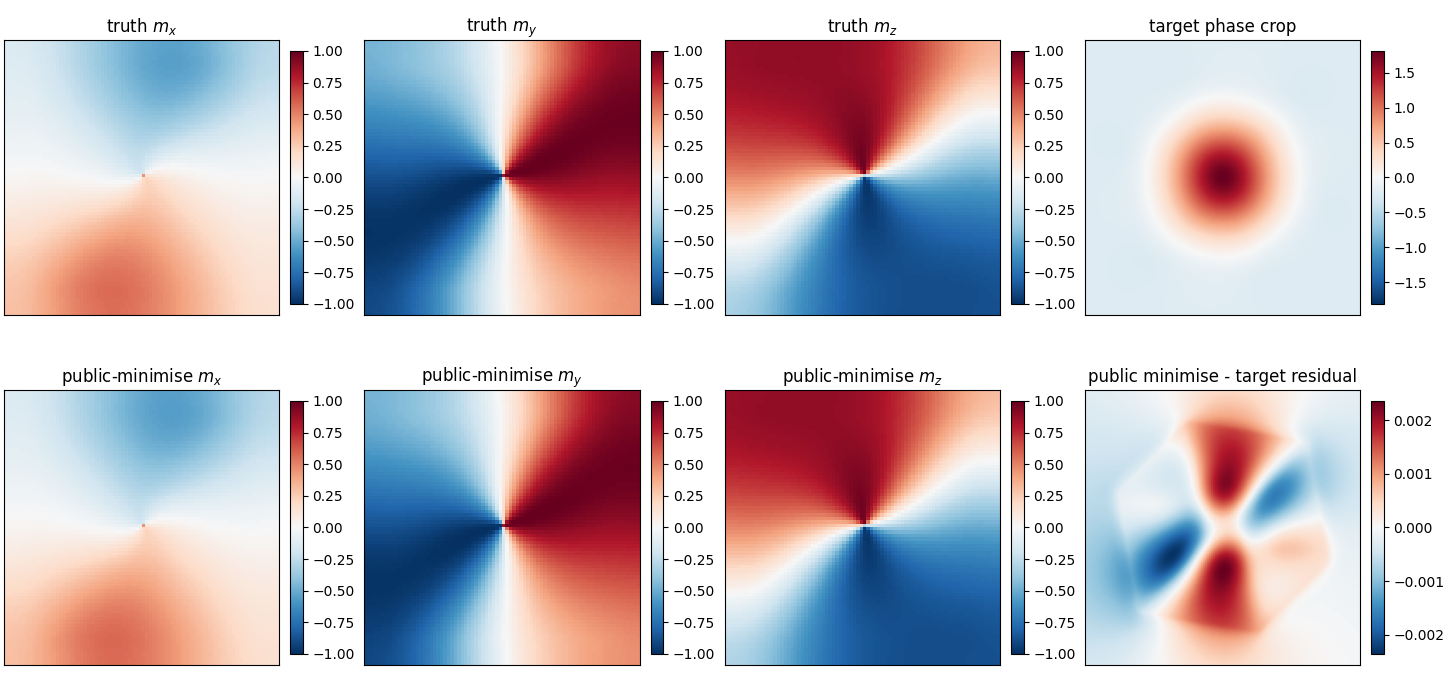

In [ ]:
target_crop_centered = center_np(target_phase_crop)
public_phase_crop_centered = center_np(public_phase_crop)
public_residual_crop = mean_subtracted_residual_np(public_phase_crop, target_phase_crop)
public_phase_lim = max(np.max(np.abs(target_crop_centered)), np.max(np.abs(public_phase_crop_centered)), 1e-12)
public_resid_lim = max(np.max(np.abs(public_residual_crop)), 1e-12)

fig, axs = plt.subplots(2, 4, figsize=(14.5, 7.0), constrained_layout=True)
mid = n // 2
for ax, image, title in [
    (axs[0, 0], truth_m_cell[:, :, mid, 0].T, "truth $m_x$"),
    (axs[0, 1], truth_m_cell[:, :, mid, 1].T, "truth $m_y$"),
    (axs[0, 2], truth_m_cell[:, :, mid, 2].T, "truth $m_z$"),
    (axs[1, 0], public_m_cell[:, :, mid, 0].T, "public-minimise $m_x$"),
    (axs[1, 1], public_m_cell[:, :, mid, 1].T, "public-minimise $m_y$"),
    (axs[1, 2], public_m_cell[:, :, mid, 2].T, "public-minimise $m_z$"),
]:
    im = ax.imshow(image, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

im = axs[0, 3].imshow(target_crop_centered, cmap="RdBu_r", vmin=-public_phase_lim, vmax=public_phase_lim)
axs[0, 3].set_title("target phase crop")
axs[0, 3].set_xticks([])
axs[0, 3].set_yticks([])
fig.colorbar(im, ax=axs[0, 3], fraction=0.046, pad=0.04)

im = axs[1, 3].imshow(public_residual_crop, cmap="RdBu_r", vmin=-public_resid_lim, vmax=public_resid_lim)
axs[1, 3].set_title("public minimise - target residual")
axs[1, 3].set_xticks([])
axs[1, 3].set_yticks([])
fig.colorbar(im, ax=axs[1, 3], fraction=0.046, pad=0.04)
plt.show()